In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,DualTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('NACC_normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'E:/code/NACC_nii_no/NACC_nii_no/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('NACC_ad.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/NACC_nii_ad/NACC_nii_ad/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('NACC_mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/NACC_mci/NACC_mci/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #713
print(count_no) #2116
print(count_mci) #879

713
2116
879


In [ ]:
import math
import numpy as np

# 基础替换字典 (请根据NACC的具体字符继续补充)
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0', 'ind': '3', 'ans': '4', 'no': '0', 'yes': '1', 'haw': '3'}

# EHR 模块 (53维): 人口学 (3-7) + 病史 (60-107)
ehr_cols = [3, 4, 5, 6, 7] + list(range(60, 108))

# BIO 模块 (43维): apoe (8) + 认知量表与问卷 (18-59)
bio_cols = [8] + list(range(18, 60))

# 统一且安全的预处理函数
def preprocess_data(data, replace_dict, target_cols):
    processed_data = []
    for row in data:
        # 仅提取安全的特征列
        extracted_row = [row[idx] for idx in target_cols]
        # 字典映射替换
        extracted_row = [replace_dict.get(item, item) for item in extracted_row]
        
        numerical_row = []
        for item in extracted_row:
            try:
                val = float(item)
                # 拦截 NaN，替换为 0.0
                if math.isnan(val):
                    val = 0.0
            except ValueError:
                # 无法转换的值替换为 0.0
                val = 0.0 
            numerical_row.append(val)
            
        processed_data.append(numerical_row)
    return np.array(processed_data)

In [ ]:
import torch
import torch.nn as nn

# 1. 提取脱敏后的 EHR 数组 (真实的 59 维特征)
ad_ehr_data = preprocess_data(data_ad, replace_dict, ehr_cols)
normal_ehr_data = preprocess_data(data_normal, replace_dict, ehr_cols)
mci_ehr_data = preprocess_data(data_mci, replace_dict, ehr_cols)

# 2. 直接转换为 Tensor
ad_EHR = torch.from_numpy(ad_ehr_data).float()
normal_EHR = torch.from_numpy(normal_ehr_data).float()
mci_EHR = torch.from_numpy(mci_ehr_data).float()

# 添加线性层将53维降维到1维，保证下游DualTransformer拼接维度一致
linear_layer = nn.Linear(53, 16)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

linear_layer = nn.Linear(16, 1)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

# 3. 打印结果检查维度
print('ad.EHR--->', ad_EHR.shape)
print('normal.EHR--->', normal_EHR.shape)
print('mci.EHR--->', mci_EHR.shape)

ad.EHR---> torch.Size([713, 1])
normal.EHR---> torch.Size([2116, 1])
mci.EHR---> torch.Size([879, 1])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)

In [10]:
import torch
import gc  # 引入垃圾回收模块

# 1. 确保模型在评估模式 (关闭 Dropout/BatchNorm 的训练行为)
nii = CNN_3D(num_class=1)
nii = nii.to(device)
nii.eval()  # 【关键点1】设置为评估模式

# 定义清理显存的函数
def clear_gpu_cache():
    gc.collect()
    torch.cuda.empty_cache() # 如果是 AMD GPU (HIP)，这个函数同样有效

# ================= 处理 AD 数据 =================
print("正在处理 AD 数据...")
all_ad = 'NACC_nii_ad'
dataset = NiiDataset(all_ad)
# 【建议】3D图像显存占用极大，如果还会爆，请将 batch_size 调小，例如 8 或 4
batch_size = 16 
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

all_outputs = []

# 【关键点2】使用 no_grad 禁止构建计算图，节省大量显存
with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        # 【关键点3】将结果移回 CPU 再存入列表，防止 GPU 显存堆积
        all_outputs.append(output.cpu()) 

# 在 CPU 上进行拼接
ad_output = torch.cat(all_outputs, dim=0)
print('ad nii shape--->', ad_output.shape)

# 【关键点4】手动清理引用和显存
del all_outputs, dataset, dataloader
clear_gpu_cache()

# ================= 处理 Normal 数据 =================
print("正在处理 Normal 数据...")
all_normal = 'NACC_nii_no'
dataset = NiiDataset(all_normal)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

all_outputs = []
with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        all_outputs.append(output.cpu()) # 移至 CPU

normal_output = torch.cat(all_outputs, dim=0)
print('normal nii shape--->', normal_output.shape)

# 清理
del all_outputs, dataset, dataloader
clear_gpu_cache()

# ================= 处理 MCI 数据 =================
print("正在处理 MCI 数据...")
all_mci = 'NACC_mci'
dataset = NiiDataset(all_mci)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

all_outputs = []
with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        all_outputs.append(output.cpu()) # 移至 CPU

mci_output = torch.cat(all_outputs, dim=0)
print('mci nii shape--->', mci_output.shape)

# 最后如果后续步骤需要这些 Tensor 在 GPU 上，可以再 .to(device) 回去
# 但通常建议保留在 CPU，直到下一步需要计算时再上传

正在处理 AD 数据...
ad nii shape---> torch.Size([713, 1])
正在处理 Normal 数据...
normal nii shape---> torch.Size([2116, 1])
正在处理 MCI 数据...
mci nii shape---> torch.Size([879, 1])


In [11]:
# 将数据移动到 CPU
ad_EHR = ad_EHR.cpu()
mci_EHR = mci_EHR.cpu()
normal_EHR = normal_EHR.cpu()
ad_output = ad_output.cpu()
mci_output = mci_output.cpu()
normal_output = normal_output.cpu()
X_ad = torch.cat([ad_EHR, ad_output], dim=1)  
X_mci = torch.cat([mci_EHR, mci_output], dim=1)  
X_normal = torch.cat([normal_EHR, normal_output], dim=1)  
y_ad = torch.ones(len(X_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(X_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(X_normal)) * 0  # Nc 类别标签为 0
X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()
X_train, X_test, y_train, y_test = train_test_split(
    X.detach().numpy(), y.numpy(),
    test_size=0.25,
    stratify=y.numpy(),
    random_state=32
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)

In [12]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建 TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [13]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [14]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)
    
    # 计算指标
    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

In [15]:
def evaluate(model, loader, criterion):
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    total_loss = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            # 获取预测概率和预测类别
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    # 计算指标
    test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    test_f1 = f1_score(all_labels, all_preds, average='macro')
    test_recall = recall_score(all_labels, all_preds, average='macro')
    test_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, test_auc, test_f1, test_recall, test_precision

In [16]:
model = DualTransformer().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [17]:
train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []


for epoch in range(100):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_auc, test_f1, test_recall, test_precision = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    # 打印信息
    if epoch % 10 == 0: print(f"Epoch {epoch:03d} | "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")
    #print(f"Train F1: {train_f1:.4f} | Train Recall: {train_recall:.4f} | Train Precision: {train_precision:.4f}")
    #print(f"Test F1: {test_f1:.4f} | Test Recall: {test_recall:.4f} | Test Precision: {test_precision:.4f}")
    print("-" * 80)

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 000 | Train Loss: 1.0549 | Train AUC: 0.5843 | Test Loss: 1.0674 | Test AUC: 0.6849
--------------------------------------------------------------------------------
Epoch 001 | Train Loss: 0.9741 | Train AUC: 0.6513 | Test Loss: 1.0537 | Test AUC: 0.7292
--------------------------------------------------------------------------------


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 002 | Train Loss: 0.9577 | Train AUC: 0.6488 | Test Loss: 1.0414 | Test AUC: 0.7023
--------------------------------------------------------------------------------


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 080 | Train Loss: 0.7976 | Train AUC: 0.7544 | Test Loss: 0.8015 | Test AUC: 0.7561
--------------------------------------------------------------------------------


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 081 | Train Loss: 0.7809 | Train AUC: 0.7648 | Test Loss: 0.7962 | Test AUC: 0.7597
--------------------------------------------------------------------------------
Epoch 082 | Train Loss: 0.8016 | Train AUC: 0.7559 | Test Loss: 0.7982 | Test AUC: 0.7642
--------------------------------------------------------------------------------
Epoch 083 | Train Loss: 0.7913 | Train AUC: 0.7601 | Test Loss: 0.7978 | Test AUC: 0.7632
--------------------------------------------------------------------------------
Epoch 084 | Train Loss: 0.8003 | Train AUC: 0.7526 | Test Loss: 0.8113 | Test AUC: 0.7646
--------------------------------------------------------------------------------
Epoch 085 | Train Loss: 0.7925 | Train AUC: 0.7587 | Test Loss: 0.7941 | Test AUC: 0.7596
--------------------------------------------------------------------------------
Epoch 086 | Train Loss: 0.7983 | Train AUC: 0.7560 | Test Loss: 0.8043 | Test AUC: 0.7598
-------------------------------------------------------

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [18]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
# 获取预测类别
preds = np.argmax(all_probs, axis=1)
# 计算指标
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro') 
recall = recall_score(all_labels, preds, average='macro')       
f1 = f1_score(all_labels, preds, average='macro')               
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr') 
print("\n=== Final Test Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Test Metrics ===
Accuracy:  0.6149
Precision: 0.3779
Recall:    0.5159
F1 Score:  0.4341
AUC-ROC:   0.7741


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


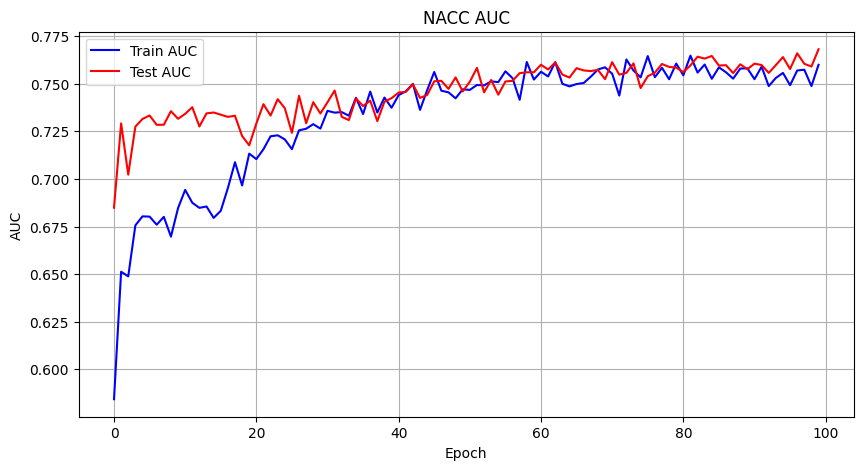

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("NACC AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.savefig('NACC_Baseline_Dual_plot.png', dpi=300)
plt.close()

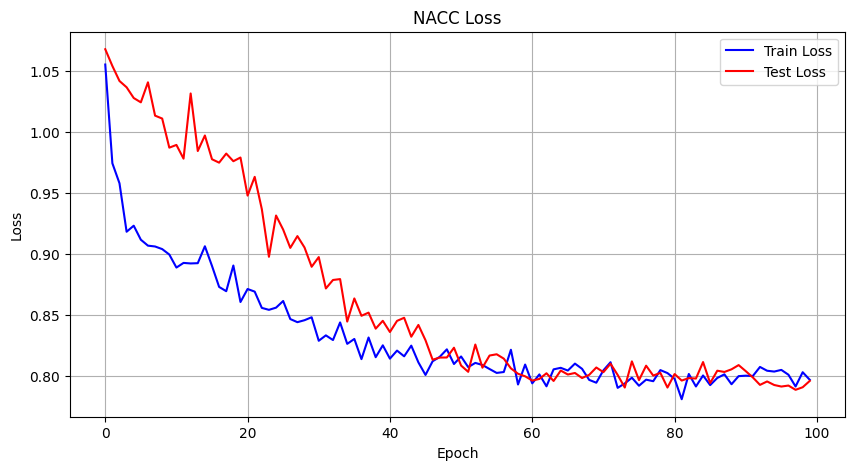

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("NACC Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig('NACC_Baseline_Dual_plot.png', dpi=300)
plt.close()

In [21]:
def evaluate_model():
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['NC', 'MCI', 'AD']))
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')  # 使用 'ovr' 或 'ovo'
    print(f"AUC Score (Ovr): {auc:.4f}")

evaluate_model()


Classification Report:
              precision    recall  f1-score   support

          NC       0.70      0.84      0.76       529
         MCI       0.00      0.00      0.00       220
          AD       0.46      0.76      0.57       178

    accuracy                           0.62       927
   macro avg       0.39      0.53      0.45       927
weighted avg       0.49      0.62      0.55       927

Confusion Matrix:
[[443   0  86]
 [146   0  74]
 [ 42   0 136]]
AUC Score (Ovr): 0.7682


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
